In [197]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [198]:
house_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Task/HousePricePrediction.xlsx 3.csv')

In [199]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [200]:
house_df.shape

(2919, 13)

In [201]:
house_df.head(3)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0


In [202]:
house_df.drop_duplicates(inplace=True)

In [203]:
house_df.shape

(2919, 13)

In [204]:
house_df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [205]:
house_df.drop(columns = ['Id'], inplace = True)

In [206]:
house_df.head(3)

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0


In [207]:
house_df.isna().sum()

,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1
BsmtFinSF2,1


In [208]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

imputer.fit(house_df[['SalePrice']])

SimpleImputer()

In [209]:
imputer.statistics_

array([180921.19589041])

In [210]:
house_df['SalePrice'] = imputer.transform(house_df[['SalePrice']])

In [211]:
house_df.isna().sum()

,0
MSSubClass,0
MSZoning,4
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,1
BsmtFinSF2,1


In [212]:
house_df = house_df.fillna(0)

In [213]:
house_df.isna().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotConfig,0
BldgType,0
OverallCond,0
YearBuilt,0
YearRemodAdd,0
Exterior1st,0
BsmtFinSF2,0


In [214]:
house_df.describe()

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.565262,1051.417266,180921.195890
std,42.517628,7886.996359,1.113131,30.291442,20.894344,169.179104,441.120498,56174.332503
min,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,163000.000000
50%,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.000000,180921.195890
75%,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,180921.195890
max,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

In [216]:
sns.set_style('darkgrid')

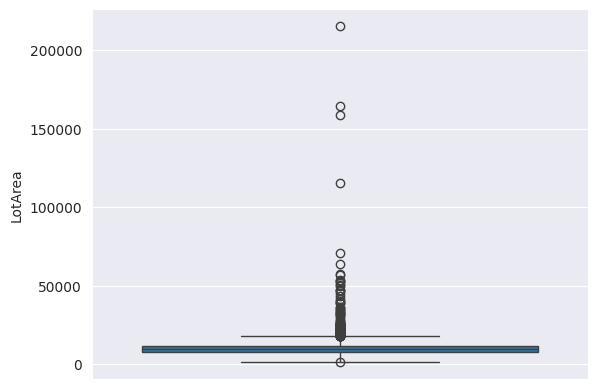

In [217]:
sns.boxplot(house_df, y = 'LotArea');

In [218]:
import numpy as np

Q1 = np.percentile(house_df['LotArea'], 25, interpolation = 'midpoint')
Q3 = np.percentile(house_df['LotArea'], 75, interpolation = 'midpoint')

IQR = Q3 - Q1

In [219]:
lowerBound = Q1 - 1.5 * IQR
upperBound = Q1 + 1.5 * IQR

In [220]:
df = house_df[(house_df.LotArea < upperBound) & (house_df.LotArea > lowerBound)]

In [221]:
df

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.00000
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.00000
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.00000
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.00000
6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,1686.0,307000.00000
...,...,...,...,...,...,...,...,...,...,...,...,...
2913,160,RM,1526,Inside,Twnhs,5,1970,1970,CemntBd,0.0,546.0,180921.19589
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,180921.19589
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,180921.19589
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,180921.19589


In [222]:
df.MSZoning.unique()

array(['RL', 'RM', 'C (all)', 'FV', 'RH'], dtype=object)

In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2550 entries, 0 to 2918
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MSSubClass    2550 non-null   int64  
 1   MSZoning      2550 non-null   object 
 2   LotArea       2550 non-null   int64  
 3   LotConfig     2550 non-null   object 
 4   BldgType      2550 non-null   object 
 5   OverallCond   2550 non-null   int64  
 6   YearBuilt     2550 non-null   int64  
 7   YearRemodAdd  2550 non-null   int64  
 8   Exterior1st   2550 non-null   object 
 9   BsmtFinSF2    2550 non-null   float64
 10  TotalBsmtSF   2550 non-null   float64
 11  SalePrice     2550 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 259.0+ KB


In [224]:
cat_cols = df.select_dtypes('object').columns.tolist()

In [225]:
cat_cols

['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']

In [226]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)

In [227]:
encoder.fit(df[cat_cols])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [228]:
encoded_cols = encoder.get_feature_names_out(cat_cols)

In [229]:
encoded_cols

array(['MSZoning_C (all)', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL',
       'MSZoning_RM', 'LotConfig_Corner', 'LotConfig_CulDSac',
       'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside',
       'BldgType_1Fam', 'BldgType_2fmCon', 'BldgType_Duplex',
       'BldgType_Twnhs', 'BldgType_TwnhsE', 'Exterior1st_AsbShng',
       'Exterior1st_AsphShn', 'Exterior1st_BrkComm',
       'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_CemntBd',
       'Exterior1st_HdBoard', 'Exterior1st_ImStucc',
       'Exterior1st_MetalSd', 'Exterior1st_Plywood', 'Exterior1st_Stucco',
       'Exterior1st_VinylSd', 'Exterior1st_Wd Sdng',
       'Exterior1st_WdShing'], dtype=object)

In [230]:
df[encoded_cols] = encoder.transform(df[cat_cols])

In [231]:
df

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,...,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,20,RL,10084,Inside,1Fam,5,2004,2005,VinylSd,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,160,RM,1526,Inside,Twnhs,5,1970,1970,CemntBd,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [232]:
df.drop(columns=cat_cols, inplace=True)

In [233]:
df

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice,MSZoning_C (all),MSZoning_FV,...,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,208500.00000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,20,9600,8,1976,1976,0.0,1262.0,181500.00000,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,60,11250,5,2001,2002,0.0,920.0,223500.00000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,70,9550,5,1915,1970,0.0,756.0,140000.00000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,20,10084,5,2004,2005,0.0,1686.0,307000.00000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,160,1526,5,1970,1970,0.0,546.0,180921.19589,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2914,160,1936,7,1970,1970,0.0,546.0,180921.19589,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2915,160,1894,5,1970,1970,0.0,546.0,180921.19589,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2917,85,10441,5,1992,1992,0.0,912.0,180921.19589,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [234]:
df.columns

Index(['MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice', 'MSZoning_C (all)',
       'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM',
       'LotConfig_Corner', 'LotConfig_CulDSac', 'LotConfig_FR2',
       'LotConfig_FR3', 'LotConfig_Inside', 'BldgType_1Fam', 'BldgType_2fmCon',
       'BldgType_Duplex', 'BldgType_Twnhs', 'BldgType_TwnhsE',
       'Exterior1st_AsbShng', 'Exterior1st_AsphShn', 'Exterior1st_BrkComm',
       'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_CemntBd',
       'Exterior1st_HdBoard', 'Exterior1st_ImStucc', 'Exterior1st_MetalSd',
       'Exterior1st_Plywood', 'Exterior1st_Stucco', 'Exterior1st_VinylSd',
       'Exterior1st_Wd Sdng', 'Exterior1st_WdShing'],
      dtype='object')

In [235]:
X = df.drop(columns = 'SalePrice')
y = df['SalePrice']

In [236]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X)

MinMaxScaler()

In [237]:
X[:] = scaler.transform(X)

In [238]:
X

,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_C (all),MSZoning_FV,MSZoning_RH,...,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,0.235294,0.574722,0.500,0.949275,0.883333,0.0,0.266999,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.000000,0.669411,0.875,0.753623,0.433333,0.0,0.393637,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.235294,0.805270,0.500,0.934783,0.866667,0.0,0.286962,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.294118,0.665294,0.500,0.311594,0.333333,0.0,0.235808,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.000000,0.709263,0.500,0.956522,0.916667,0.0,0.525889,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2913,0.823529,0.004611,0.500,0.710145,0.333333,0.0,0.170306,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2914,0.823529,0.038370,0.750,0.710145,0.333333,0.0,0.170306,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2915,0.823529,0.034911,0.500,0.710145,0.333333,0.0,0.170306,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2917,0.382353,0.738658,0.500,0.869565,0.700000,0.0,0.284467,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [239]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [240]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2040, 36), (510, 36), (2040,), (510,))

In [241]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [242]:
y_pred = model.predict(X_test)

In [243]:
y_test[:5]

,SalePrice
67,226000.00000
226,290000.00000
2546,180921.19589
268,120500.00000
2174,180921.19589


In [244]:
y_pred[:5]

array([205620.03768775, 202529.95783246, 174325.44515851, 138275.9637565 ,
       212234.25952767])

In [245]:
from sklearn.metrics import mean_absolute_error

In [246]:
mean_absolute_error(y_test, y_pred)

29949.867586195618

In [247]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=50, max_iter=100, tol = 0.1)

lasso_reg.fit(X_train, y_train)

Lasso(alpha=50, max_iter=100, tol=0.1)

In [248]:
lasso_pred = lasso_reg.predict(X_test)

In [249]:
mean_absolute_error(y_test, lasso_pred)

29916.55331889878

In [250]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=50, max_iter=100, tol = 0.1)

ridge_reg.fit(X_train, y_train)

Ridge(alpha=50, max_iter=100, tol=0.1)

In [251]:
ridge_pred = ridge_reg.predict(X_test)

In [252]:
mean_absolute_error(y_test, ridge_pred)

29945.30935306077

In [253]:
import os

os.makedirs("images", exist_ok=True)

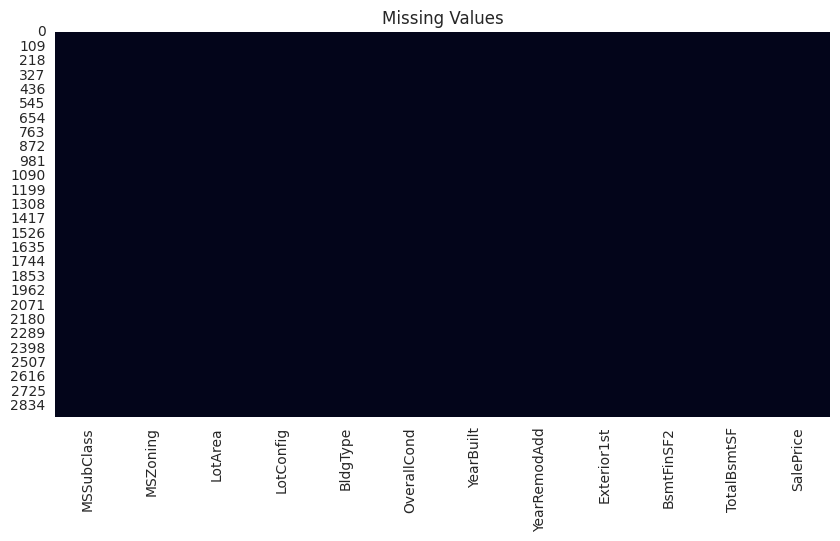

In [254]:
plt.figure(figsize=(10,5))
sns.heatmap(house_df.isnull(), cbar=False)

plt.title("Missing Values")

plt.savefig(
    "images/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

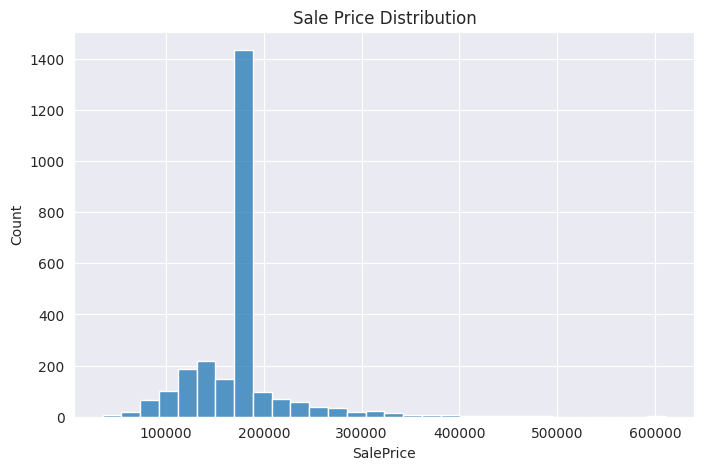

In [255]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=30)

plt.title("Sale Price Distribution")

plt.savefig(
    "images/saleprice_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

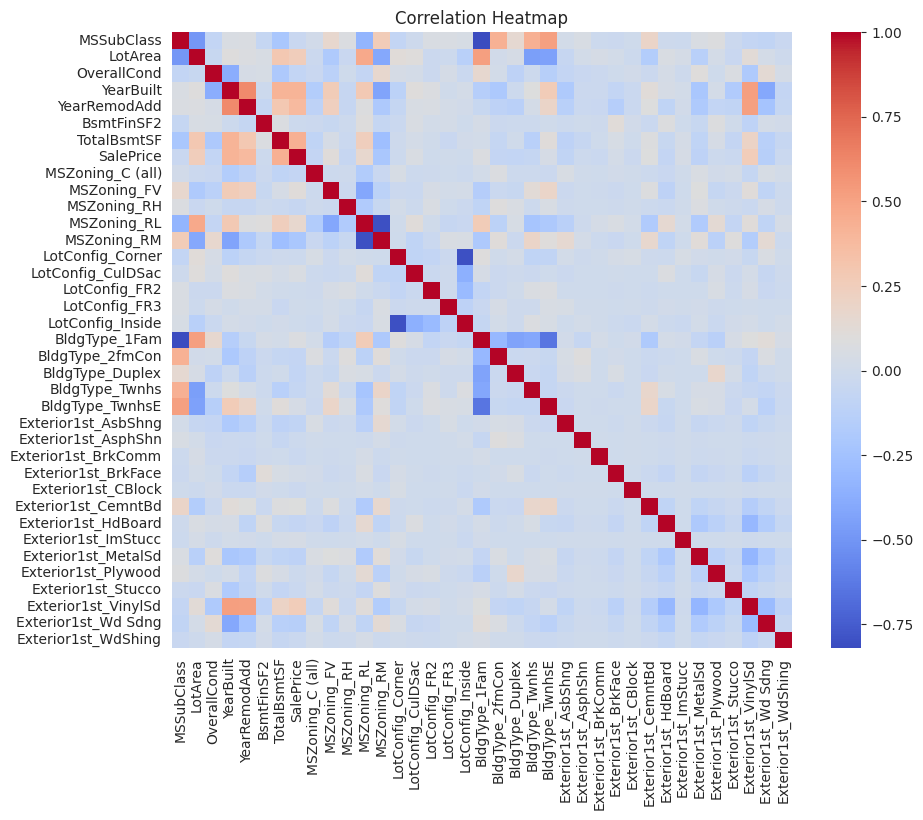

In [256]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

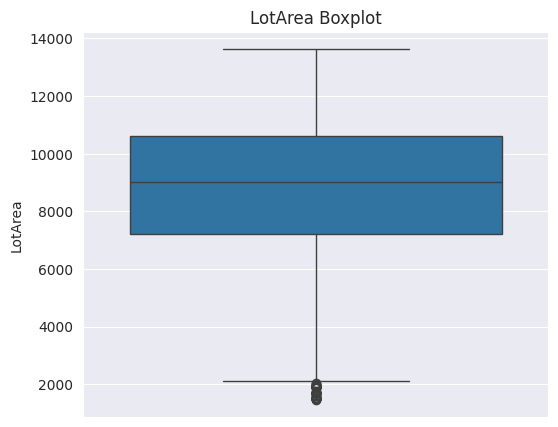

In [257]:
# LotArea Boxplot
plt.figure(figsize=(6,5))

sns.boxplot(y=df["LotArea"])

plt.title("LotArea Boxplot")

plt.savefig(
    "images/lotarea_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [261]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# Linear Regression
r2_lr = r2_score(y_test, y_pred)
mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))

# Ridge Regression
r2_ridge = r2_score(y_test, ridge_pred)
mae_ridge = mean_absolute_error(y_test, ridge_pred)
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_pred))

# Lasso Regression
r2_lasso = r2_score(y_test, lasso_pred)
mae_lasso = mean_absolute_error(y_test, lasso_pred)
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_pred))

In [262]:
results = pd.DataFrame({

'Model':[
'Linear Regression',
'Ridge Regression',
'Lasso Regression'
],

'R2 Score':[
r2_lr,
r2_ridge,
r2_lasso
],

'MAE':[
mae_lr,
mae_ridge,
mae_lasso
],

'RMSE':[
rmse_lr,
rmse_ridge,
rmse_lasso
]

})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.320289,29949.867586,41724.579589
1,Ridge Regression,0.255055,29945.309353,43680.951406
2,Lasso Regression,0.320009,29916.553319,41733.196040


In [266]:
# Model Comparison
results = pd.DataFrame({

'Model':['Linear Regression',
          'Ridge Regression',
          'Lasso Regression'],

'R2 Score':[r2_lr,r2_ridge,r2_lasso],

'MAE':[mae_lr,mae_ridge,mae_lasso],

'RMSE':[rmse_lr,rmse_ridge,rmse_lasso]

})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.320289,29949.867586,41724.579589
1,Ridge Regression,0.255055,29945.309353,43680.951406
2,Lasso Regression,0.320009,29916.553319,41733.196040


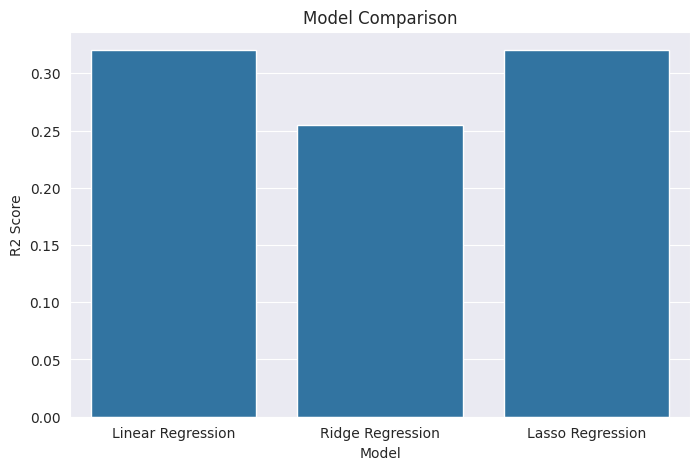

In [265]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")

plt.savefig(
    "images/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

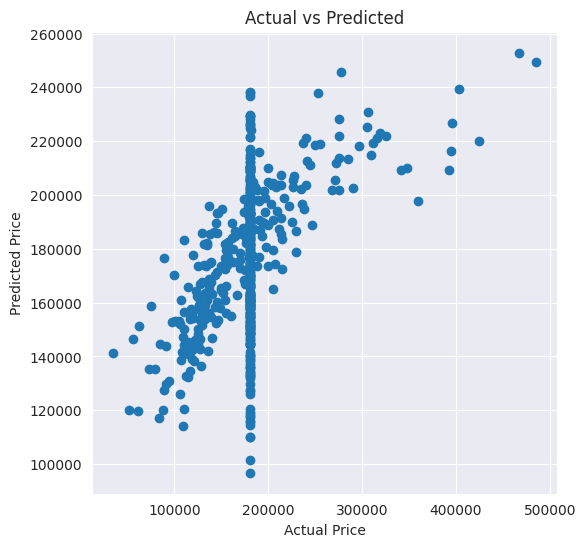

In [270]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.savefig(
    "images/actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

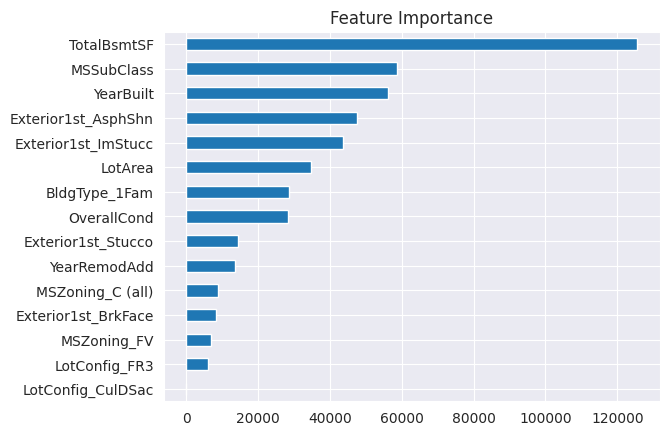

In [271]:
coef = pd.Series(model.coef_,index=X.columns)

coef.sort_values().tail(15).plot(kind="barh")

plt.title("Feature Importance")

plt.savefig(
    "images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
